# Brakujące Wartosci

##  1. Import bibliotek

In [ ]:
import numpy as np
import pandas as pd
import sklearn
sklearn.__version__

'1.6.1'

## 2. Wygenerownie danych

In [ ]:
data = {
    'size': ['XL', 'L', 'M', np.nan, 'M', 'M'],
    'color': ['red', 'green', 'blue', 'green', 'red', 'green'],
    'gender': ['female', 'male', np.nan, 'female', 'female', 'male'],
    'price': [199.0, 89.0, np.nan, 129.0, 79.0, 89.0],
    'weight': [500, 450, 300, np.nan, 410, np.nan],
    'bought': ['yes', 'no', 'yes', 'no', 'yes', 'no']

}

In [ ]:
data_raw = pd.DataFrame(data=data)
data_raw

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,M,blue,NaN,NaN,300.0,yes
3,NaN,green,female,129.0,NaN,no
4,M,red,female,79.0,410.0,yes
5,M,green,male,89.0,NaN,no


## 2. Utworzenie  kopii danych

In [ ]:
df = data_raw.copy()
df

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,M,blue,NaN,NaN,300.0,yes
3,NaN,green,female,129.0,NaN,no
4,M,red,female,79.0,410.0,yes
5,M,green,male,89.0,NaN,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   size    5 non-null      object 
 1   color   6 non-null      object 
 2   gender  5 non-null      object 
 3   price   5 non-null      float64
 4   weight  4 non-null      float64
 5   bought  6 non-null      object 
dtypes: float64(2), object(4)
memory usage: 420.0+ bytes


In [ ]:
df.isnull()

,size,color,gender,price,weight,bought
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,True,True,False,False
3,True,False,False,False,True,False
4,False,False,False,False,False,False
5,False,False,False,False,True,False


In [ ]:
df.isnull().sum()

,0
size,1
color,0
gender,1
price,1
weight,2
bought,0


In [ ]:
df.isnull().sum()/len(df)

,0
size,0.166667
color,0.000000
gender,0.166667
price,0.166667
weight,0.333333
bought,0.000000


## 3. Uzupełnianie braków - SimpleImputer

In [ ]:
from sklearn.impute import SimpleImputer

#strategy = 'mean', 'median', 'most_frequent', 'constant'

imputer = SimpleImputer(missing_values= np.nan, strategy  = 'mean')
imputer = imputer.fit(df[['weight']])
df['weight'] = imputer.transform(df[['weight']])
df

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,M,blue,NaN,NaN,300.0,yes
3,NaN,green,female,129.0,415.0,no
4,M,red,female,79.0,410.0,yes
5,M,green,male,89.0,415.0,no


In [ ]:
imputer = SimpleImputer(missing_values= np.nan, strategy  = 'constant', fill_value = 99.0)
df['price'] = imputer.fit_transform(df[['price']]).ravel()
df


,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,M,blue,NaN,99.0,300.0,yes
3,NaN,green,female,129.0,415.0,no
4,M,red,female,79.0,410.0,yes
5,M,green,male,89.0,415.0,no


In [ ]:
imputer = SimpleImputer(missing_values= np.nan, strategy  = 'constant', fill_value = 'L')
df['size'] = imputer.fit_transform(df[['size']]).ravel()
df

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,M,blue,NaN,99.0,300.0,yes
3,L,green,female,129.0,415.0,no
4,M,red,female,79.0,410.0,yes
5,M,green,male,89.0,415.0,no


In [ ]:
df = data_raw.copy()
df

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,M,blue,NaN,NaN,300.0,yes
3,NaN,green,female,129.0,NaN,no
4,M,red,female,79.0,410.0,yes
5,M,green,male,89.0,NaN,no


In [ ]:
pd.isnull(df['weight'])

,weight
0,False
1,False
2,False
3,True
4,False
5,True


In [ ]:
df[pd.isnull(df['weight'])]

,size,color,gender,price,weight,bought
3,NaN,green,female,129.0,NaN,no
5,M,green,male,89.0,NaN,no


In [ ]:
df[~pd.isnull(df['weight'])]

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,M,blue,NaN,NaN,300.0,yes
4,M,red,female,79.0,410.0,yes


In [ ]:
df.fillna(value= 0.0)

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,M,blue,0.0,0.0,300.0,yes
3,0.0,green,female,129.0,0.0,no
4,M,red,female,79.0,410.0,yes
5,M,green,male,89.0,0.0,no


In [ ]:
df['size'] = df['size'].fillna(value='L')
df

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,M,blue,NaN,NaN,300.0,yes
3,L,green,female,129.0,NaN,no
4,M,red,female,79.0,410.0,yes
5,M,green,male,89.0,NaN,no


## 4. Usuwanie braków

In [ ]:
df.dropna()

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
4,M,red,female,79.0,410.0,yes


In [ ]:
df = df.dropna(subset=['size'])
df

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,M,blue,NaN,NaN,300.0,yes
3,L,green,female,129.0,NaN,no
4,M,red,female,79.0,410.0,yes
5,M,green,male,89.0,NaN,no


In [ ]:
df = df.dropna(subset=['weight'])
df

,size,color,gender,price,weight,bought
0,XL,red,female,199.0,500.0,yes
1,L,green,male,89.0,450.0,no
2,M,blue,NaN,NaN,300.0,yes
4,M,red,female,79.0,410.0,yes


# Braki danych w szeregach czasowych

## Wygenerowanie danych

In [ ]:
data = {'price' : [108,109,110,110,109, np.nan, np.nan, 112,111,111]}
date_range  = pd.date_range(start = '01-01-2020 09:00', end = '01-01-2020 18:00', periods =10)

In [ ]:
df = pd.DataFrame(data = data, index = date_range)

## Wykresy

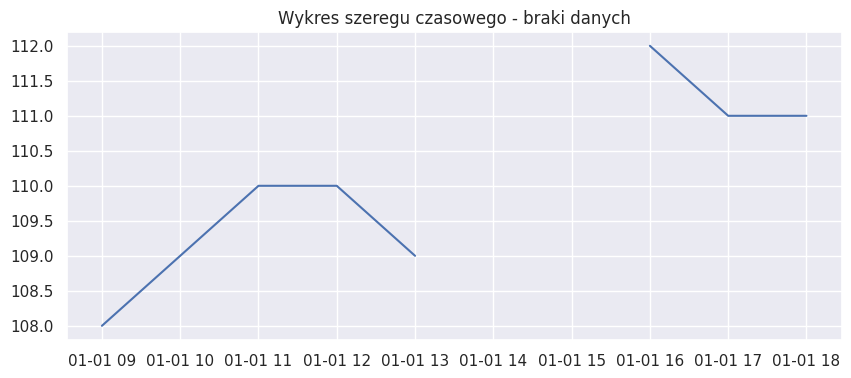

In [ ]:
from pandas.plotting import register_matplotlib_converters
import matplotlib.pyplot as plt
import seaborn as sns
register_matplotlib_converters()
sns.set()
plt.figure(figsize = (10,4))
plt.title('Wykres szeregu czasowego - braki danych')
_ = plt.plot(df.price)

In [ ]:
import plotly.express as px
df_ploty = df.reset_index()
px.line(df_ploty, 'index', 'price', width = 600, height = 400, title = 'Szeregi czasowe - braki danych')

In [ ]:
px.line(df_ploty, 'price', 'index', width = 600, height = 400, title = 'Szeregi czasowe - braki danych')

## Usunięcie brakow

In [ ]:
df_ploty = df.reset_index()
px.line(df_ploty.dropna(), 'index', 'price', width = 600, height = 400, title = 'Szeregi czasowe - usunięceie braków danych')

## Wstawienie wartości stałej/średniej

In [ ]:
df_ploty = df.reset_index()
df_ploty['price_fil'] = df_ploty['price'].fillna(0)

px.line(df_ploty, 'index', 'price_fil', width = 600, height = 400, title = 'Szeregi czasowe - wstawienie 0')

In [ ]:
df_ploty = df.reset_index()
df_ploty['price_fill'] = df_ploty['price'].fillna(df_ploty['price'].mean())
px.line(df_ploty, 'index', 'price_fill', width = 600, height = 400, title = 'Szeregi czasowe - wstawienie sredniej')

## Interpolacja

In [ ]:
# Interpolacja to metoda matematyczna i statystyczna polegająca
# na szacowaniu nieznanych wartości na podstawie znanych punktów danych, które
#  znajdują się wewnątrz zakresu posiadanych obserwacji.
# Najprościej mówiąc: jeśli masz dwa znane punkty na wykresie,
# interpolacja pozwala Ci "zgadnąć", jakie wartości przyjmuje funkcja pomiędzy nimi.

In [ ]:
df_ploty = df.reset_index()
df_ploty['price_interp'] = df_ploty['price'].interpolate()
px.line(df_ploty, 'index', 'price_interp', width = 600, height = 400,
        title = 'Szeregi czasowe - interpolacja')

## Forward fill

In [ ]:
df_ploty = df.reset_index()
df_ploty['price_ffill'] = df_ploty['price'].ffill()
px.line(df_ploty, 'index', 'price_ffill', width = 600, height = 400,
        title = 'Szeregi czasowe - forward fill')

## Backward fill

In [ ]:
df_ploty = df.reset_index()
df_ploty['price_bfill'] = df_ploty['price'].bfill()
px.line(df_ploty, 'index', 'price_bfill', width = 600, height = 400,
        title = 'Szeregi czasowe - backward fill')